In [7]:
# 优化方法：
# 1. 梯度下降：沿梯度方向将增加损失函数值，沿梯度下降方向。学习率：步长的超参数 
# 2. 小批量随机梯度下降：整个训练集上算梯度太贵，一个dnn模型可能星雨数分钟至数小时；随机采样b个样本i1，i2，。。。ib来近似损失，1/b sum l（xi，yi，w），b是批量大小，另一个重要的超参数
#    选择批量大小：不能太小：计算量太小，不适合并行最大利用计算资源；不能太大：内存消耗增加，浪费计算，例如所有样本相同
#    小批量随机梯度下降是深度学习默认的求解算法，两个重要的超参数是批量大小和学习率

# 线性回归的从零实现：包括数据流水线，模型，损失函数和小批量随机梯度下降优化器
%matplotlib inline
import random
import torch
from d2l import torch as d2l

# 根据带有噪声的线性模型构造一个人造数据集。使用线性模型参数 w=[2, -3.4]T,b=4.2和噪声项epsilon生成数据集及其标签
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声。"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:', features[0], '\nlabel:', labels[0])

features: tensor([ 0.1918, -0.5268]) 
label: tensor([6.3883])


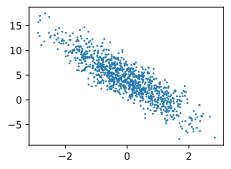

In [8]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [9]:
# 定义一个data_iter函数，该函数接收批量大小、特征矩阵和标签向量作为输入，生成大小为batch_size的小批量
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-1.8461,  1.7396],
        [ 1.4680, -0.4178],
        [-0.3297, -1.8386],
        [ 0.7323, -1.5082],
        [ 0.8317,  0.6890],
        [-0.0280, -2.1377],
        [-1.3253,  0.1494],
        [ 1.0431, -0.9414],
        [-1.6126, -0.5133],
        [-0.4798, -0.5129]]) 
 tensor([[-5.4021],
        [ 8.5723],
        [ 9.7975],
        [10.7911],
        [ 3.5276],
        [11.3965],
        [ 1.0607],
        [ 9.4871],
        [ 2.7285],
        [ 4.9762]])


In [35]:
# 定义初始化模型参数
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [31]:
def linreg(X, x, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [32]:
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape))**2 / 2

In [23]:
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [36]:
lr = 10
num_epochs = 10
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss nan
epoch 2, loss nan
epoch 3, loss nan
epoch 4, loss nan
epoch 5, loss nan
epoch 6, loss nan
epoch 7, loss nan
epoch 8, loss nan
epoch 9, loss nan
epoch 10, loss nan


In [34]:
# 比较真实参数和通过训练学到的参数来评估训练的成功程度
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([7.3314e-04, 7.2241e-05], grad_fn=<SubBackward0>)
b的估计误差: tensor([-4.7684e-06], grad_fn=<RsubBackward1>)


In [50]:
# linear regression的简洁实现
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 200)

In [51]:
# 调用框架中现有的API来读取数据
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个pytorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

next(iter(data_iter))

[tensor([[-0.4049, -0.4590],
         [ 1.2808, -1.3397],
         [-0.6213,  0.6423],
         [ 0.3165,  1.9211],
         [-0.1419,  0.3697],
         [ 1.0099,  0.2887],
         [ 0.5468,  0.8219],
         [ 0.8100, -0.6440],
         [ 0.8236,  0.6276],
         [-0.3560,  0.0402]]),
 tensor([[ 4.9451],
         [11.3167],
         [ 0.7776],
         [-1.6880],
         [ 2.6405],
         [ 5.2415],
         [ 2.5080],
         [ 8.0292],
         [ 3.6988],
         [ 3.3513]])]

In [41]:
next(iter(data_iter))

[tensor([[ 0.1360,  0.0196],
         [-0.7565, -1.1973],
         [ 0.1003, -0.4042],
         [-0.2686,  1.4090],
         [ 0.1919,  2.2933],
         [ 0.6565,  0.3374],
         [ 1.5756, -0.5245],
         [-0.4170, -1.3830],
         [-0.9746,  0.8102],
         [ 0.3349,  1.0464]]),
 tensor([[ 4.3989],
         [ 6.7587],
         [ 5.7805],
         [-1.1459],
         [-3.2168],
         [ 4.3658],
         [ 9.1223],
         [ 8.0755],
         [-0.5019],
         [ 1.3123]])]

In [52]:
# 使用框架的预定义好的层
# 'nn'是神经网络的缩写
from torch import nn
net = nn.Sequential(nn.Linear(2, 1))
# 初始化模型参数
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [53]:
# 计算均方误差使用的是MSELoss类，也称为L2范数
loss = nn.MSELoss()
# 实例化SGD实例
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [55]:
# 训练过程代码
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.001992
epoch 2, loss 0.000296
epoch 3, loss 0.000120
